# Phase 4: Signal Generation and Baseline Backtest
Build rule-based mean-reversion signals using rolling Z-score and evaluate performance.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path('../data')
OUT_DIR = Path('../outputs')

prices = pd.read_csv(DATA_DIR / 'nifty_prices_clean.csv', index_col=0, parse_dates=True)
pairs = pd.read_csv(DATA_DIR / 'selected_pairs.csv')

pair = pairs.iloc[0]
a, b = pair['stock_a'], pair['stock_b']
beta_static = float(pair['beta_a_on_b'])

print(f'Using pair: {a} vs {b}')
print(f'Static beta from train: {beta_static:.4f}')

Using pair: HEROMOTOCO.NS vs EICHERMOT.NS
Static beta from train: 0.6994


In [2]:
# Optional rolling beta for realism
window_beta = 252
beta_roll = prices[a].rolling(window_beta).cov(prices[b]) / prices[b].rolling(window_beta).var()
beta = beta_roll.fillna(beta_static)

spread = prices[a] - beta * prices[b]
z_window = 30
z = (spread - spread.rolling(z_window).mean()) / spread.rolling(z_window).std()

df = pd.DataFrame({
    'price_a': prices[a],
    'price_b': prices[b],
    'beta': beta,
    'spread': spread,
    'zscore': z,
}).dropna()

display(df.head())

,price_a,price_b,beta,spread,zscore
Date,,,,,
2015-02-12,1986.483521,1517.127319,0.699395,925.412767,-1.215110
2015-02-13,2018.571289,1503.215454,0.699395,967.230420,-0.733529
2015-02-16,1984.679199,1483.228149,0.699395,947.317344,-0.903778
2015-02-18,1884.737427,1566.042725,0.699395,789.455499,-2.497170
2015-02-19,1885.586792,1537.682983,0.699395,810.139516,-2.090558


In [3]:
# Trading rules
entry = 2.0
exit_band = 0.5

position = []
pos = 0
for val in df['zscore']:
    if pos == 0:
        if val > entry:
            pos = -1  # short spread
        elif val < -entry:
            pos = 1   # long spread
    else:
        if abs(val) < exit_band:
            pos = 0
    position.append(pos)

df['position'] = pd.Series(position, index=df.index)
df['position_lag'] = df['position'].shift(1).fillna(0)

ret_a = df['price_a'].pct_change().fillna(0)
ret_b = df['price_b'].pct_change().fillna(0)
spread_ret = ret_a - df['beta'] * ret_b

# Cost applied on position change
cost = 0.001  # 10 bps
turnover = df['position'].diff().abs().fillna(0)
strategy_ret = df['position_lag'] * spread_ret - turnover * cost

df['strategy_ret'] = strategy_ret
df['equity'] = (1 + df['strategy_ret']).cumprod()
df['buyhold_spread'] = (1 + spread_ret.fillna(0)).cumprod()

df[['strategy_ret', 'equity']].tail()

,strategy_ret,equity
Date,,
2024-12-24,0.010640,1.041406
2024-12-26,-0.002275,1.039036
2024-12-27,0.021453,1.061327
2024-12-30,0.008430,1.070274
2024-12-31,0.000986,1.071329


In [4]:
def perf_stats(returns: pd.Series, name: str) -> dict:
    returns = returns.dropna()
    ann_factor = 252
    cagr = (1 + returns).prod() ** (ann_factor / len(returns)) - 1
    vol = returns.std() * np.sqrt(ann_factor)
    sharpe = (returns.mean() * ann_factor) / (returns.std() * np.sqrt(ann_factor) + 1e-12)
    eq = (1 + returns).cumprod()
    dd = eq / eq.cummax() - 1
    mdd = dd.min()
    return {'strategy': name, 'CAGR': cagr, 'Vol': vol, 'Sharpe': sharpe, 'MaxDD': mdd}

stats = pd.DataFrame([
    perf_stats(df['strategy_ret'], 'zscore_strategy'),
    perf_stats(spread_ret.fillna(0), 'raw_spread_buyhold'),
])
display(stats)

stats.to_csv(DATA_DIR / 'baseline_backtest_stats.csv', index=False)
print('Saved: ../data/baseline_backtest_stats.csv')

,strategy,CAGR,Vol,Sharpe,MaxDD
0,zscore_strategy,0.007147,0.225381,0.144245,-0.428682
1,raw_spread_buyhold,-0.093427,0.292352,-0.189095,-0.642067


Saved: ../data/baseline_backtest_stats.csv


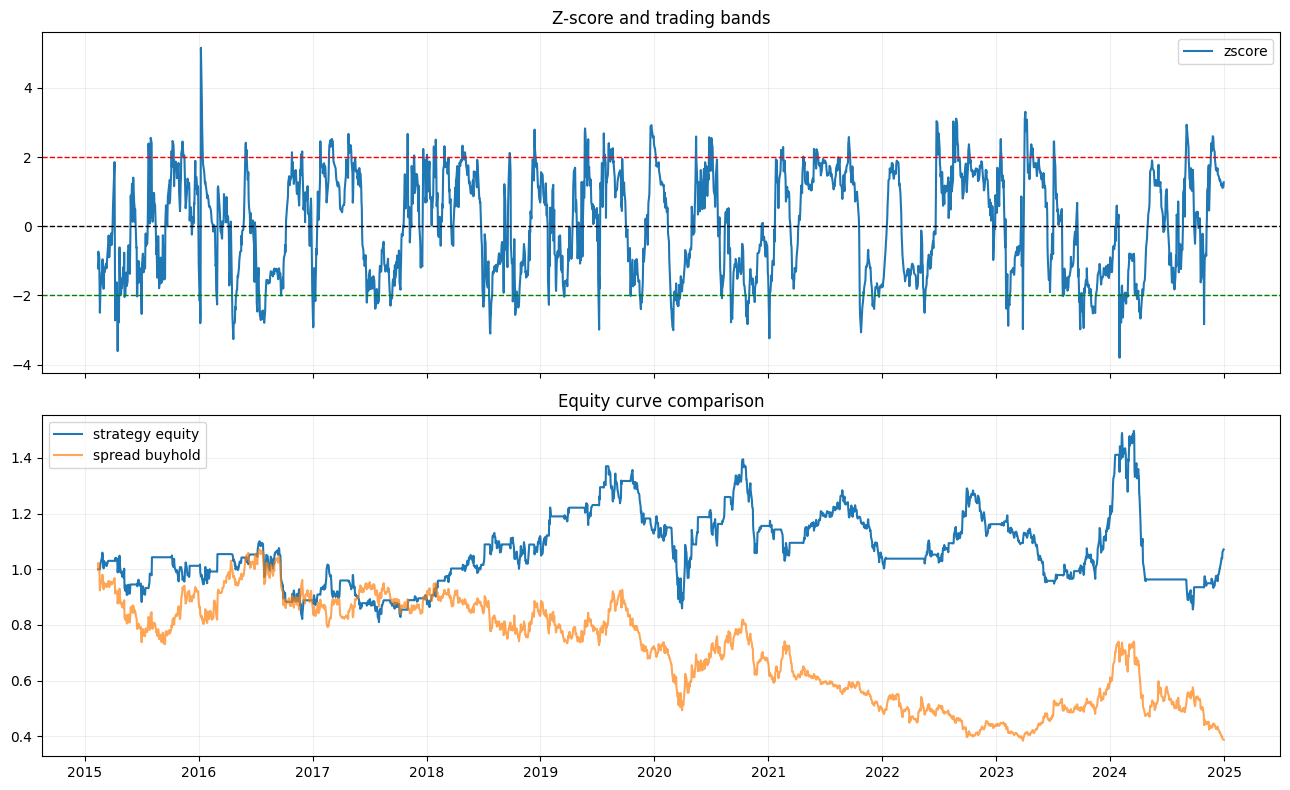

Saved: ../outputs/05_baseline_equity_curve.png
Saved: ../data/baseline_trade_series.csv


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(df.index, df['zscore'], label='zscore')
axes[0].axhline(2, color='r', ls='--', lw=1)
axes[0].axhline(-2, color='g', ls='--', lw=1)
axes[0].axhline(0, color='black', ls='--', lw=1)
axes[0].set_title('Z-score and trading bands')
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(df.index, df['equity'], label='strategy equity')
axes[1].plot(df.index, df['buyhold_spread'], label='spread buyhold', alpha=0.7)
axes[1].set_title('Equity curve comparison')
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig(OUT_DIR / '05_baseline_equity_curve.png', dpi=140, bbox_inches='tight')
plt.show()

df.to_csv(DATA_DIR / 'baseline_trade_series.csv')
print('Saved: ../outputs/05_baseline_equity_curve.png')
print('Saved: ../data/baseline_trade_series.csv')